# Nice Plot Viz for Publications

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks")
from loading_utils import load_root_file, load_hepmc_event

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Roadmap

1. Load an edm4hep file
2. Load the particles, tracker hits and calo hits


## Loading

In [3]:
f = uproot.open("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/0/performance_finding_ckf_graphs.root")

In [ ]:
gr = f["trackeff_vs_pT_gr"]
# x, y points
x, y = gr.values()
ex_low  = gr.errors("low",  axis=0)
ex_high = gr.errors("high", axis=0)
ey_low  = gr.errors("low",  axis=1)
ey_high = gr.errors("high", axis=1)

In [4]:
gr = f["trackeff_vs_eta_gr"]
# x, y points
x, y = gr.values()
ex_low  = gr.errors("low",  axis=0)
ex_high = gr.errors("high", axis=0)
ey_low  = gr.errors("low",  axis=1)
ey_high = gr.errors("high", axis=1)

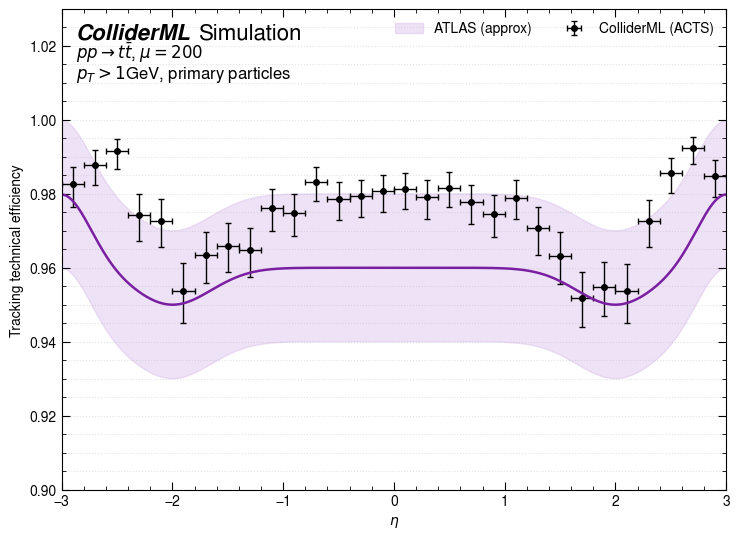

In [14]:
# Efficiency vs eta with ATLAS- and CMS-style envelopes
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# ColliderML measurement
ax.errorbar(
    x, y,
    xerr=(ex_low, ex_high), yerr=(ey_low, ey_high),
    fmt='o', ms=4, color='black', ecolor='black', elinewidth=1.0, capsize=2,
    label='ColliderML (ACTS)'
)

# Common eta grid
eta_grid = np.linspace(-4.0, 4.0, 800)

# ATLAS-inspired tracking efficiency envelope
# Targets (approx): 0.98 at |eta|=3, 0.95 at |eta|=2, 0.96 at 0
w_peak = 0.25
w_dip  = 0.35
f_mid_atlas = (
    0.96
    - 0.01 * np.exp(-0.5 * ((eta_grid - 2.0) / w_dip) ** 2)
    - 0.01 * np.exp(-0.5 * ((eta_grid + 2.0) / w_dip) ** 2)
    + 0.02 * np.exp(-0.5 * ((eta_grid - 3.0) / w_peak) ** 2)
    + 0.02 * np.exp(-0.5 * ((eta_grid + 3.0) / w_peak) ** 2)
)
# Soft bounds around the mid curve (±0.5%)
band = 0.02
f_lo_atlas = np.clip(f_mid_atlas - band, 0.0, 1.0)
f_hi_atlas = np.clip(f_mid_atlas + band, 0.0, 1.0)

atlas_color = '#7b1fa2'     # purple
atlas_light = '#d1aee6'     # light purple
ax.fill_between(eta_grid, f_lo_atlas, f_hi_atlas, color=atlas_light, alpha=0.35, label='ATLAS (approx)')
ax.plot(eta_grid, f_mid_atlas, color=atlas_color, linewidth=1.8)

# CMS-inspired tracking efficiency envelope (approx from Phase-2 fig)
# Plateau ~0.94 with dips near |eta|~1.5 and rapid edge fall-off near |eta|>3.6
w_cms_dip   = 0.28
w_cms_peak  = 0.35
edge_scale  = 0.36  # depth of edge fall to ~0.6 at |eta|~4
edge_width  = 0.08
f_mid_cms = (
    0.945
    - 0.07 * np.exp(-0.5 * ((eta_grid - 1.55) / w_cms_dip) ** 2)
    - 0.07 * np.exp(-0.5 * ((eta_grid + 1.55) / w_cms_dip) ** 2)
    + 0.01 * np.exp(-0.5 * ((eta_grid - 3.0) / w_cms_peak) ** 2)
    + 0.01 * np.exp(-0.5 * ((eta_grid + 3.0) / w_cms_peak) ** 2)
)
# Edge roll-off using a smooth logistic on |eta|
edge = edge_scale * (1.0 / (1.0 + np.exp(-(np.abs(eta_grid) - 3.6) / edge_width)))
f_mid_cms = np.clip(f_mid_cms - edge, 0.0, 1.0)

f_lo_cms = np.clip(f_mid_cms - band, 0.0, 1.0)
f_hi_cms = np.clip(f_mid_cms + band, 0.0, 1.0)

cms_color = '#c62828'      # deep red
cms_light = '#f1b7b7'      # light red

# Don't show CMS right now - need to understand how they define their efficiency
# ax.fill_between(eta_grid, f_lo_cms, f_hi_cms, color=cms_light, alpha=0.35, label='CMS (approx)')
# ax.plot(eta_grid, f_mid_cms, color=cms_color, linewidth=1.8)

# Axes, limits, labels
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(0.90, 1.00)
ax.set_xlabel(r"$\eta$")
ax.set_ylabel("Tracking technical efficiency")
ax.grid(True, which='both', axis='y', linestyle=':', alpha=0.35)
ax.legend(frameon=False, loc='upper right', ncol=2)

# ATLAS-style label
try:
    atl.atlasify(
        "Simulation",
        "\n".join([
            r"$pp \rightarrow t\bar{t}$, $\mu = 200$",
            r"$p_T > 1$GeV, primary particles"
        ]),
        axes=ax
    )
except Exception:
    pass

plt.tight_layout()
plt.savefig('tracking_efficiency_comparison.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()